# Initial Data Exploration

This notebook is the first port of call for understanding the data we are dealing with. We have a notebook with 7 columns:
* 'from' - a datetime for the 30-minute time window after the quoted datetime
* 'carbon_intensity_actual' - the reported carbon intensity for this 30-minute window in gCO2/kWh
* 'carbon_intensity_forecast' - the forecasted carbon intensity (should only be used for model output comparison) in gCO2/kWh
* 'demand' - the demand on the energy grid for this 30-minute window (how much energy is necessary to meet the countries energy needs) in kWh
* 'Solar' - the contribution of solar energy production in meeting the demand in this 30-minute window in kWh
* 'Wind Offshore' - the contribution of offshore wind energy production in meeting the demand in this 30-minute window in kWh
* 'Wind Onshore' - the contribution of onshore wind energy production in meeting the demand in this 30-minute window in kWh

## Import packages

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [60]:
figure_path = "data/outputs/figures/exploration/"

## Read in CSV file

In [61]:
data = pd.read_csv(
    "data/carbon_intensity_demand_solar_wind_2022-01-01_2023-01-01.csv",
    parse_dates=["from"],
)

In [62]:
data.head()

,from,carbon_intensity_actual,carbon_intensity_forecast,demand,"""Solar""","""Wind Offshore""","""Wind Onshore"""
0,2022-01-01 00:00:00+00:00,74.0,74,21690,0.0,6480.583,4739.050
1,2022-01-01 00:30:00+00:00,75.0,70,21830,0.0,6480.583,4739.050
2,2022-01-01 01:00:00+00:00,73.0,70,21335,0.0,6708.648,5380.218
3,2022-01-01 01:30:00+00:00,68.0,61,20239,0.0,6708.648,5380.218
4,2022-01-01 02:00:00+00:00,71.0,62,19224,0.0,6978.515,6059.516


Make the T=0 30-min interval datetime the dataframe index

In [63]:
data = data.sort_values("from")
data = data.set_index("from")

Add two columns to the dataframe - residual_demand and renewables. Both of these are approximated as forecasted power generation using carbon emitting sources (natural gas, imports, coal, etc.) and renewable energy sources, respectively. The former contribute to the carbon intensity whilst the latter do not.

In [64]:
data["residual_demand"] = (
    data["demand"] - data['"Solar"'] - data['"Wind Offshore"'] - data['"Wind Onshore"']
)
data["renewables"] = data['"Solar"'] + data['"Wind Offshore"'] + data['"Wind Onshore"']

# Row, Column Analysis

## Shapes and Types

First to last row datetime: 2022-01-01 00:00:00+00:00 -> 2023-01-01 23:30:00+00:00

In [65]:
data.shape

(17568, 8)

In [66]:
data.dtypes

carbon_intensity_actual      float64
carbon_intensity_forecast      int64
demand                         int64
"Solar"                      float64
"Wind Offshore"              float64
"Wind Onshore"               float64
residual_demand              float64
renewables                   float64
dtype: object

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17568 entries, 2022-01-01 00:00:00+00:00 to 2023-01-01 23:30:00+00:00
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   carbon_intensity_actual    17517 non-null  float64
 1   carbon_intensity_forecast  17568 non-null  int64  
 2   demand                     17568 non-null  int64  
 3   "Solar"                    17280 non-null  float64
 4   "Wind Offshore"            17280 non-null  float64
 5   "Wind Onshore"             17280 non-null  float64
 6   residual_demand            17280 non-null  float64
 7   renewables                 17280 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 1.2 MB


## NaN Analysis

NaN count per column

In [68]:
data.isnull().sum()

carbon_intensity_actual       51
carbon_intensity_forecast      0
demand                         0
"Solar"                      288
"Wind Offshore"              288
"Wind Onshore"               288
residual_demand              288
renewables                   288
dtype: int64

Missing %, worst column first

In [69]:
data.isnull().mean().sort_values(ascending=False) * 100

"Solar"                      1.639344
"Wind Offshore"              1.639344
"Wind Onshore"               1.639344
residual_demand              1.639344
renewables                   1.639344
carbon_intensity_actual      0.290301
carbon_intensity_forecast    0.000000
demand                       0.000000
dtype: float64

In [70]:
data[data['"Solar"'].isnull()].index.normalize().unique()

DatetimeIndex(['2022-04-11 00:00:00+00:00', '2022-05-26 00:00:00+00:00',
               '2022-12-05 00:00:00+00:00', '2022-12-13 00:00:00+00:00',
               '2022-12-19 00:00:00+00:00', '2022-12-23 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='from', freq=None)

In [71]:
data[data["carbon_intensity_actual"].isnull()].index.normalize().unique()

DatetimeIndex(['2022-03-26 00:00:00+00:00', '2022-12-09 00:00:00+00:00',
               '2022-12-10 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='from', freq=None)

Rows with any NaN inputs

In [72]:
data[data.isnull().any(axis=1)]

,carbon_intensity_actual,carbon_intensity_forecast,demand,"""Solar""","""Wind Offshore""","""Wind Onshore""",residual_demand,renewables
from,,,,,,,,
2022-03-26 18:00:00+00:00,NaN,244,31327,118.0,1396.742,913.989,28898.269,2428.731
2022-03-26 18:30:00+00:00,NaN,240,32100,0.0,1396.742,913.989,29789.269,2310.731
2022-03-26 19:00:00+00:00,NaN,241,32087,0.0,1456.941,859.678,29770.381,2316.619
2022-03-26 19:30:00+00:00,NaN,244,31165,0.0,1456.941,859.678,28848.381,2316.619
2022-03-26 20:00:00+00:00,NaN,247,30135,0.0,1463.062,842.929,27829.009,2305.991
...,...,...,...,...,...,...,...,...
2022-12-23 21:30:00+00:00,79.0,91,28105,NaN,NaN,NaN,NaN,NaN
2022-12-23 22:00:00+00:00,82.0,83,26668,NaN,NaN,NaN,NaN,NaN
2022-12-23 22:30:00+00:00,82.0,78,25008,NaN,NaN,NaN,NaN,NaN


Any duplicate rows

In [73]:
data.duplicated().sum()
data[data.duplicated()]

,carbon_intensity_actual,carbon_intensity_forecast,demand,"""Solar""","""Wind Offshore""","""Wind Onshore""",residual_demand,renewables
from,,,,,,,,


Mean, standard deviation, min/max, quartiles

In [74]:
data.describe(include="all")

,carbon_intensity_actual,carbon_intensity_forecast,demand,"""Solar""","""Wind Offshore""","""Wind Onshore""",residual_demand,renewables
count,17517.000000,17568.000000,17568.000000,17280.000000,17280.000000,17280.000000,17280.000000,17280.000000
mean,182.344465,180.836692,26632.262750,1381.532350,4967.231497,4016.342273,16206.068938,10365.106119
std,65.177925,65.299081,6124.913375,2047.163016,3294.405877,2576.526666,8232.640259,5669.331035
min,39.000000,29.000000,14390.000000,0.000000,163.648000,361.584000,-9770.109000,671.961000
25%,131.000000,129.000000,21856.000000,0.000000,2013.016000,1792.945750,10482.053750,5730.140000
50%,191.000000,189.000000,25952.000000,32.000000,4326.297500,3545.269000,16220.000000,9807.892500
75%,236.000000,234.000000,30199.000000,2375.000000,7829.436750,5945.079750,21352.489750,14608.364750
max,322.000000,380.000000,48313.000000,9015.000000,12864.358000,10502.339000,45582.282000,28149.620000


In [ ]:
data.skew()  # which columns (if any) are skewed

carbon_intensity_actual     -0.276891
carbon_intensity_forecast   -0.245609
demand                       0.594678
"Solar"                      1.454602
"Wind Offshore"              0.376505
"Wind Onshore"               0.530709
residual_demand              0.190571
renewables                   0.352303
dtype: float64

Strong negative correlation of carbon intensity with renewables, as expected

In [77]:
data.corr()["carbon_intensity_actual"].sort_values()

renewables                  -0.819920
"Wind Offshore"             -0.801626
"Wind Onshore"              -0.740852
"Solar"                     -0.046638
demand                       0.285608
residual_demand              0.776360
carbon_intensity_forecast    0.978728
carbon_intensity_actual      1.000000
Name: carbon_intensity_actual, dtype: float64

<Axes: >

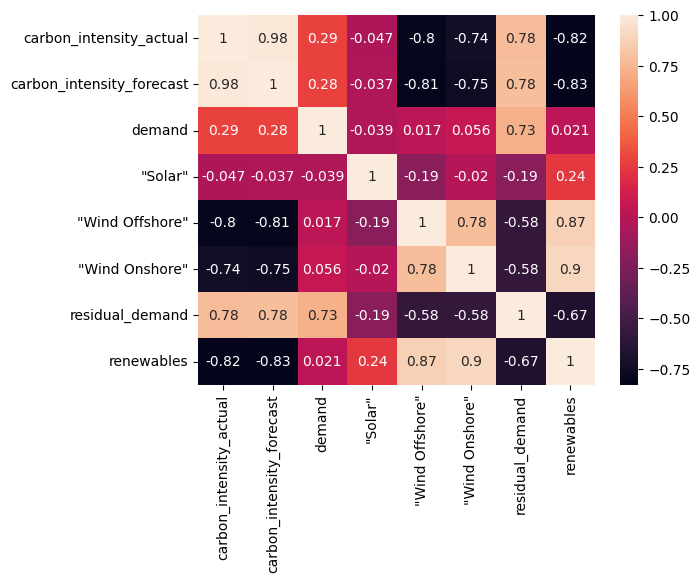

In [78]:
sns.heatmap(data.corr(), annot=True)

In [79]:
data.index.to_series().diff().value_counts()  # check for gaps/irregular intervals

from
0 days 00:30:00    17567
Name: count, dtype: int64

# Plots and Analysis

## Overview of Energy Generation for the year

#### (albeit all forecasted data)

A stacked plot of the ~renewable energy sources (forecasted) and the residual demand (~contributions from carbon emitting sources)

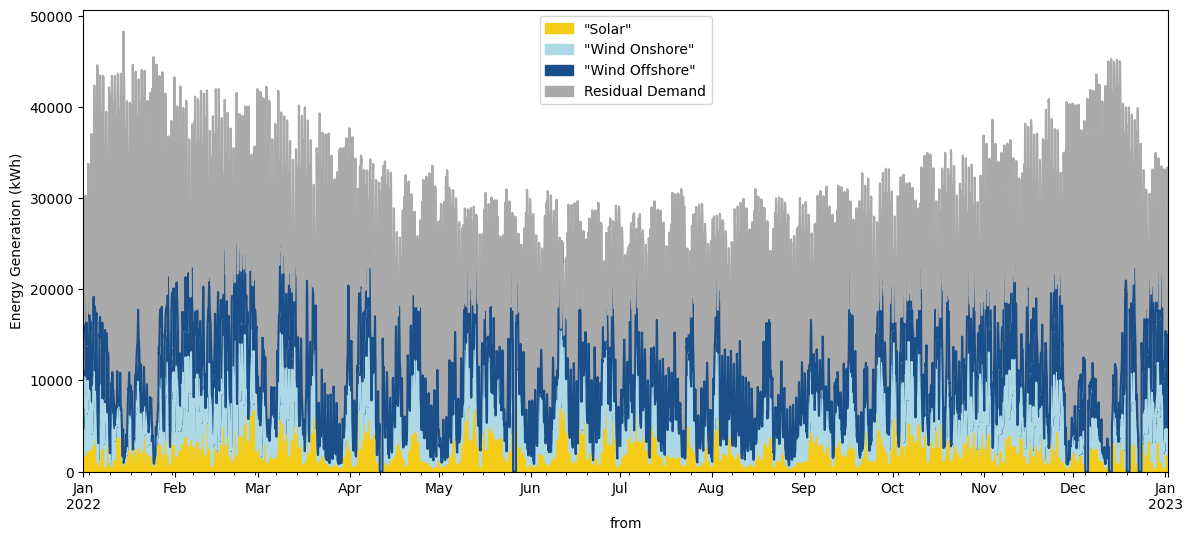

In [80]:
renewables = ['"Solar"', '"Wind Onshore"', '"Wind Offshore"']

plot_data = data[renewables + ["demand"]].copy()
plot_data["Residual Demand"] = (data["demand"] - data[renewables].sum(axis=1)).clip(
    lower=0
)
color_map = {
    '"Solar"': "#F5CD18",
    '"Wind Onshore"': "#ADD8E6",
    '"Wind Offshore"': "#1B4F8A",
    "Residual Demand": "#AAAAAA",
}
cols = [*renewables, "Residual Demand"]

fig, ax = plt.subplots(figsize=(14, 6))
plot_data[cols].plot.area(stacked=True, color=[color_map[c] for c in cols], ax=ax)
ax.legend()
plt.ylabel("Energy Generation (kWh)")
plt.savefig(f"{figure_path}energy_generation_overview.png", dpi=150)
plt.show()

## Correlation between Residual Demand and Carbon Intensity

If the "residual demand" is assumed to be contributions that are carbon emitting, we would expect to see a positive correlation with the carbon intensity. A 2D histogram plot is shown below, with carbon intensity vs residual demand, showing a positive correlation.
We see the R^2 value for the linear fit is _just_ over 0.6, signifying a significant positive correlation between the two variables. This means that 60% of the variance in the carbon intensity can be explained by the "residual demand". Therefore, there is 40% not being captured, which is caused by other factors and variables which are not being taken into account in this simple plot.

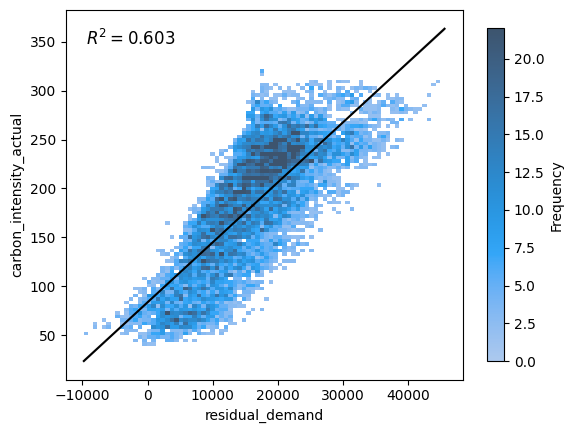

In [81]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="residual_demand",
    y="carbon_intensity_actual",
    bins=80,
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9, label="Frequency"),
    ax=ax,
)

sns.regplot(
    data,
    x="residual_demand",
    y="carbon_intensity_actual",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["residual_demand", "carbon_intensity_actual"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["residual_demand"]), list(data_tmp["carbon_intensity_actual"])
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}residual_demand_vs_carbon_intensity.png", dpi=150)

## Correlation between Renewables and Carbon Intensity

With the above logic, you would also expect a negative correlation between the carbon intensity and the renewable contributions. This is plotted below and we can see a significant negative correlation with and R^2 = 0.672.

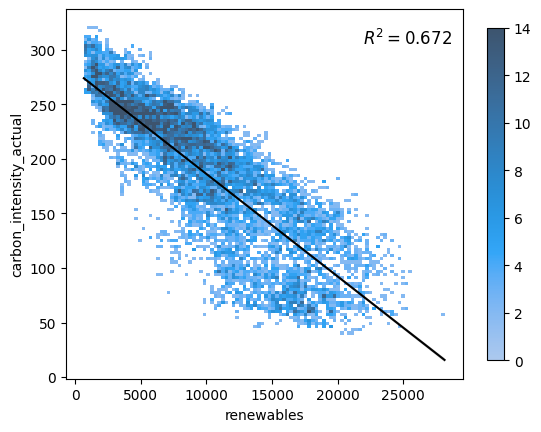

In [82]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="renewables",
    y="carbon_intensity_actual",
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x="renewables",
    y="carbon_intensity_actual",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["renewables", "carbon_intensity_actual"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["renewables"]), list(data_tmp["carbon_intensity_actual"])
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.75, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}renewables_gen_vs_carbon_intensity.png", dpi=150)

## Correlation between Renewables Contrbution (as %) and Carbon Intensity

In [83]:
data["renewable_%"] = data["renewables"] / data["demand"]

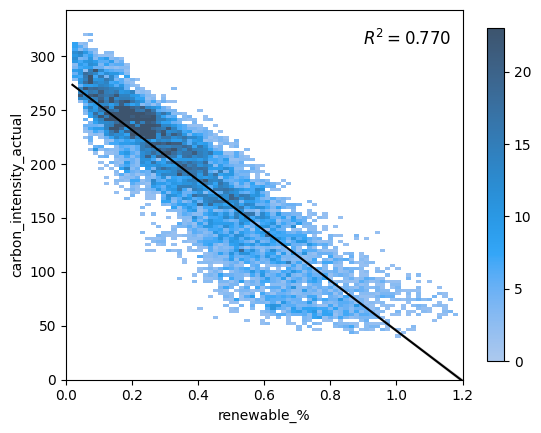

In [84]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="renewable_%",
    y="carbon_intensity_actual",
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x="renewable_%",
    y="carbon_intensity_actual",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["renewable_%", "carbon_intensity_actual"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["renewable_%"]), list(data_tmp["carbon_intensity_actual"])
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.75, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)
plt.xlim(0, 1.2)
plt.ylim(0)
plt.savefig(f"{figure_path}ren_perc_vs_carbon_intensity.png", dpi=150)

## Correlation between Carbon Intensity Actual and Carbon Intensity Forecast (Day-before)

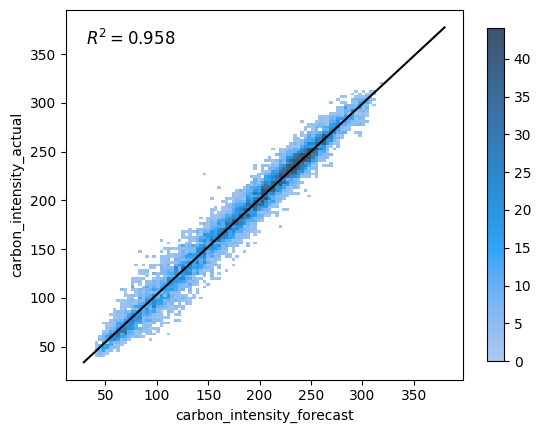

In [85]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="carbon_intensity_forecast",
    y="carbon_intensity_actual",
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x="carbon_intensity_forecast",
    y="carbon_intensity_actual",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["carbon_intensity_forecast", "carbon_intensity_actual"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["carbon_intensity_forecast"]),
    list(data_tmp["carbon_intensity_actual"]),
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}carbon_intensity_actual_vs_forecast.png", dpi=150)

## Correlation between Carbon Intensity Actual+30 mins and Carbon Intensity Actual

"carbon_intensity_30min_shift" - shift the carbon intensity (actual) by 30 minutes and plot the correlation between the two. This will give an indication on the predictability of the next time step T+1 using the current timestep T. 

In [86]:
data["carbon_intensity_30min_shift"] = data["carbon_intensity_actual"].shift(-1)

As can be seen in the plot below, sequential carbon intensity values are highly correlated, with an R^2 of 0.99. This means that carbon intensity at T+1 is highly correlated with carbon intensity at T. This is as expected, the state of the energy grid does not change much in a 30 minute window throughout the year. 

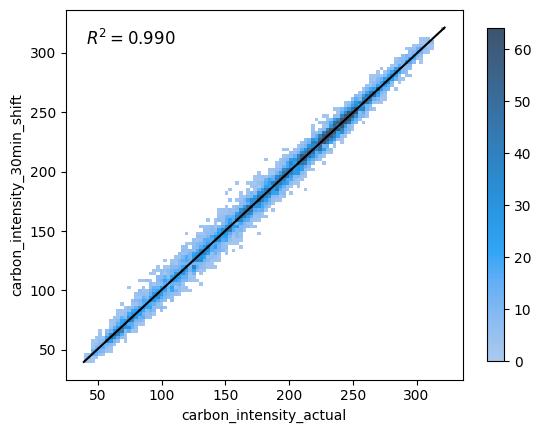

In [ ]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="carbon_intensity_actual",
    y="carbon_intensity_30min_shift",
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x="carbon_intensity_actual",
    y="carbon_intensity_30min_shift",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["carbon_intensity_actual", "carbon_intensity_30min_shift"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["carbon_intensity_actual"]),
    list(data_tmp["carbon_intensity_30min_shift"]),
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}carbon_intensity_shift_compare_0.5hr.png", dpi=150)

## Correlation between Carbon Intensity Actual+24hr and Carbon Intensity Actual

We will now do the same thing again but for the maximum forecast time, 24 hours ahead. Here, we shift the carbon intensity actual by 48 (30 minute) timesteps and plot the correlation.

In [88]:
data["carbon_intensity_24hr_shift"] = data["carbon_intensity_actual"].shift(-48)

The plot is below. As expected, the strength of the correlation is far weaker compared to a 30-minute window. This is also as expected, the state of the energy grid is dependent on a variety of different variables such as weather and demand which are not captured by solely the 24-hr lagged carbon intensity value

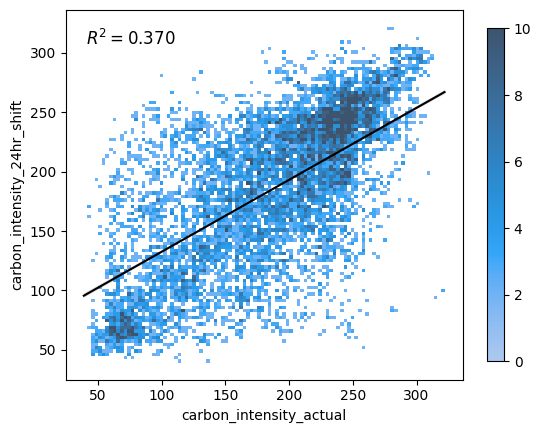

In [89]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x="carbon_intensity_actual",
    y="carbon_intensity_24hr_shift",
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x="carbon_intensity_actual",
    y="carbon_intensity_24hr_shift",
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[["carbon_intensity_actual", "carbon_intensity_24hr_shift"]].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp["carbon_intensity_actual"]),
    list(data_tmp["carbon_intensity_24hr_shift"]),
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}carbon_intensity_shift_compare_24hr.png", dpi=150)

## Correlation between Offshore Wind and Onshore Wind

There is a correlation here, but best to keep these as separate variables in the training as 40% of variance not covered by correlation

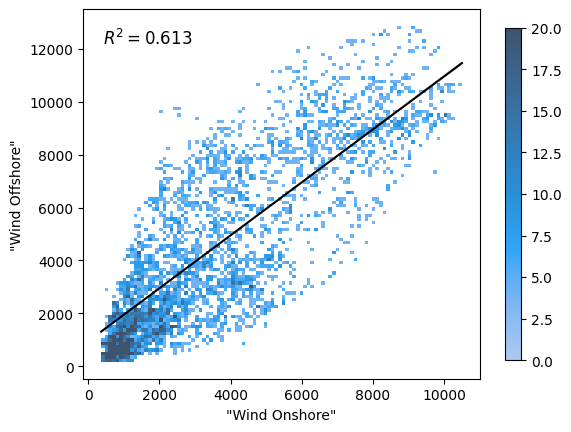

In [90]:
fig, ax = plt.subplots()

sns.histplot(
    data,
    x='"Wind Onshore"',
    y='"Wind Offshore"',
    bins=100,
    log_scale=(False, False),
    pthresh=0,
    pmax=0.9,
    cbar=True,
    cbar_kws=dict(shrink=0.9),
)

sns.regplot(
    data,
    x='"Wind Onshore"',
    y='"Wind Offshore"',
    scatter=False,
    line_kws={"color": "k", "linewidth": 1.5},
    ax=ax,
)

data_tmp = data[['"Wind Onshore"', '"Wind Offshore"']].dropna()

slope, intercept, r, p, se = stats.linregress(
    list(data_tmp['"Wind Onshore"']), list(data_tmp['"Wind Offshore"'])
)

ax.annotate(
    f"$R^2 = {r**2:.3f}$",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    fontsize=12,
    va="top",
)

plt.savefig(f"{figure_path}wind_onshore_vs_wind_offshore.png", dpi=150)

# Carbon Intensity vs Time Interval Averages

Below are some time averaged plots for the columns to get an idea of daily, monthly, seasonal, yearly variations

In [91]:
def plot_column(col, colormap="twilight"):
    fig, axes = plt.subplots(3, 2, figsize=(10, 14))
    fig.suptitle(col)

    data.groupby("hour").mean().plot(
        y=col, ax=axes[0, 0], title="Avg by Hour", legend=False
    )
    data.groupby(["month", "hour"]).mean()[col].unstack(0).plot(
        ax=axes[0, 1], colormap=colormap, title="Hour by Month"
    )

    data.groupby("day_of_week").mean().plot(
        y=col, ax=axes[1, 0], title="Avg by Day of Week", legend=False
    )
    data.groupby(["month", "day_of_week"]).mean()[col].unstack(0).plot(
        ax=axes[1, 1], colormap=colormap, title="Day of Week by Month"
    )

    data.groupby("month").mean().plot(ax=axes[2, 0], y=col, title="Avg by Month")
    data.groupby("day_of_year").mean().plot(
        ax=axes[2, 1], y=col, title="Avg by Day of Year"
    )

    plt.tight_layout()
    plt.savefig(f"{figure_path}time_trends_{col}.png", dpi=150)
    plt.show()

In [92]:
data["date"] = data.index
data["hour"] = data["date"].dt.hour
data["day_of_week"] = data["date"].dt.dayofweek
data["day_of_year"] = data["date"].dt.dayofyear
data["month"] = data["date"].dt.month

Two peaks are visible, one in the morning and one in the evening - this aligns with waking up, getting ready for work and coming home from work, making dinner and relaxing (using electrical applicances)

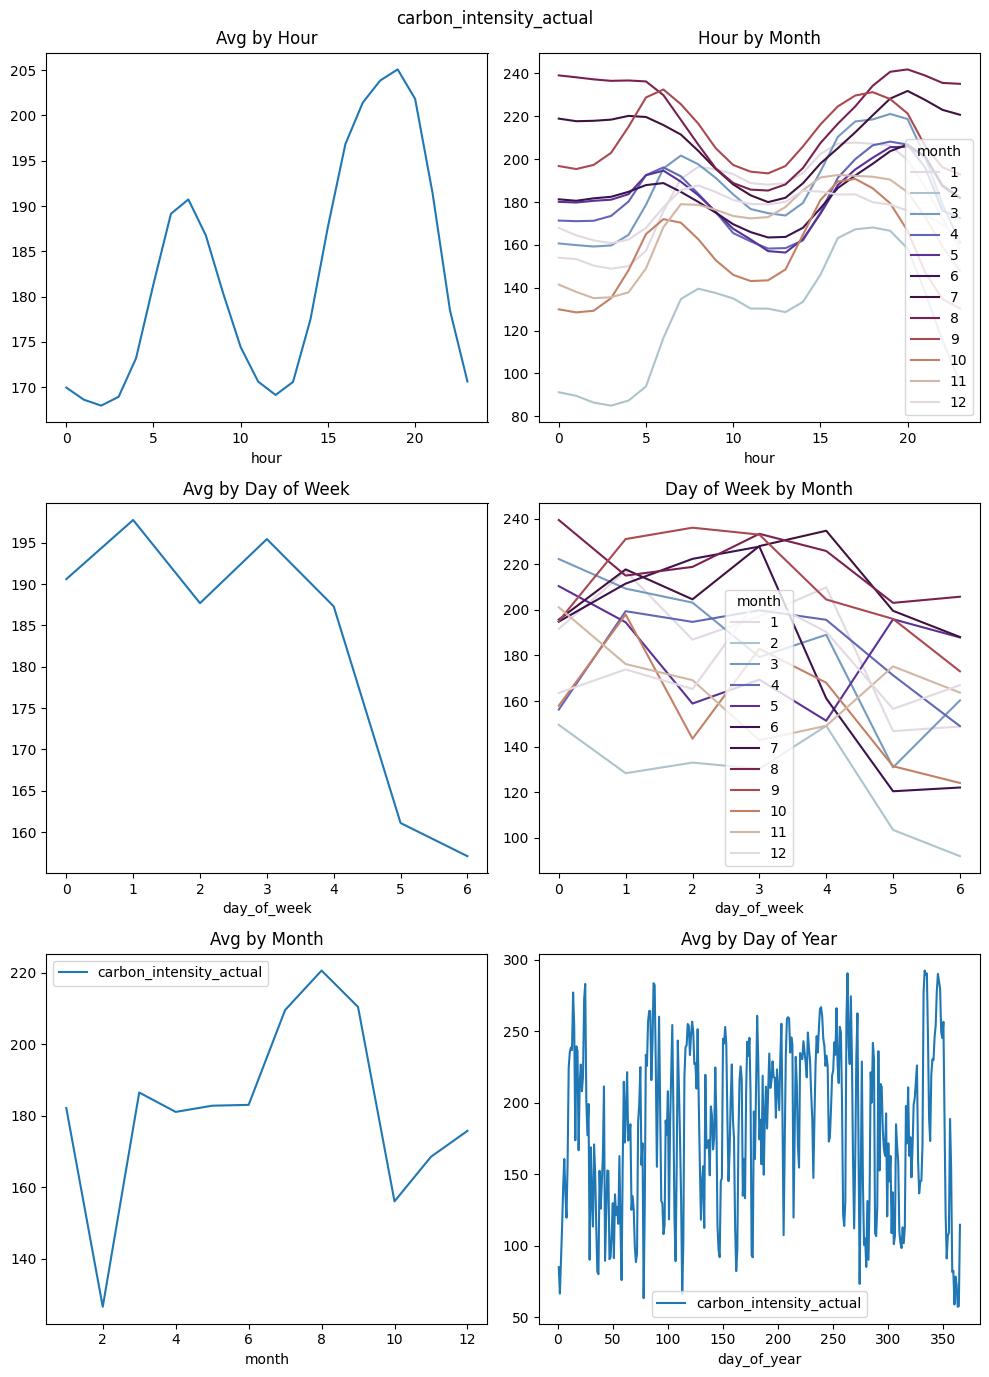

In [93]:
plot_column("carbon_intensity_actual")

Let's now deconstruct it by month. We se quite a lot of variation. The daily average in January is wildly different to July.

# Solar Generation (forecast) vs Time Interval Averages

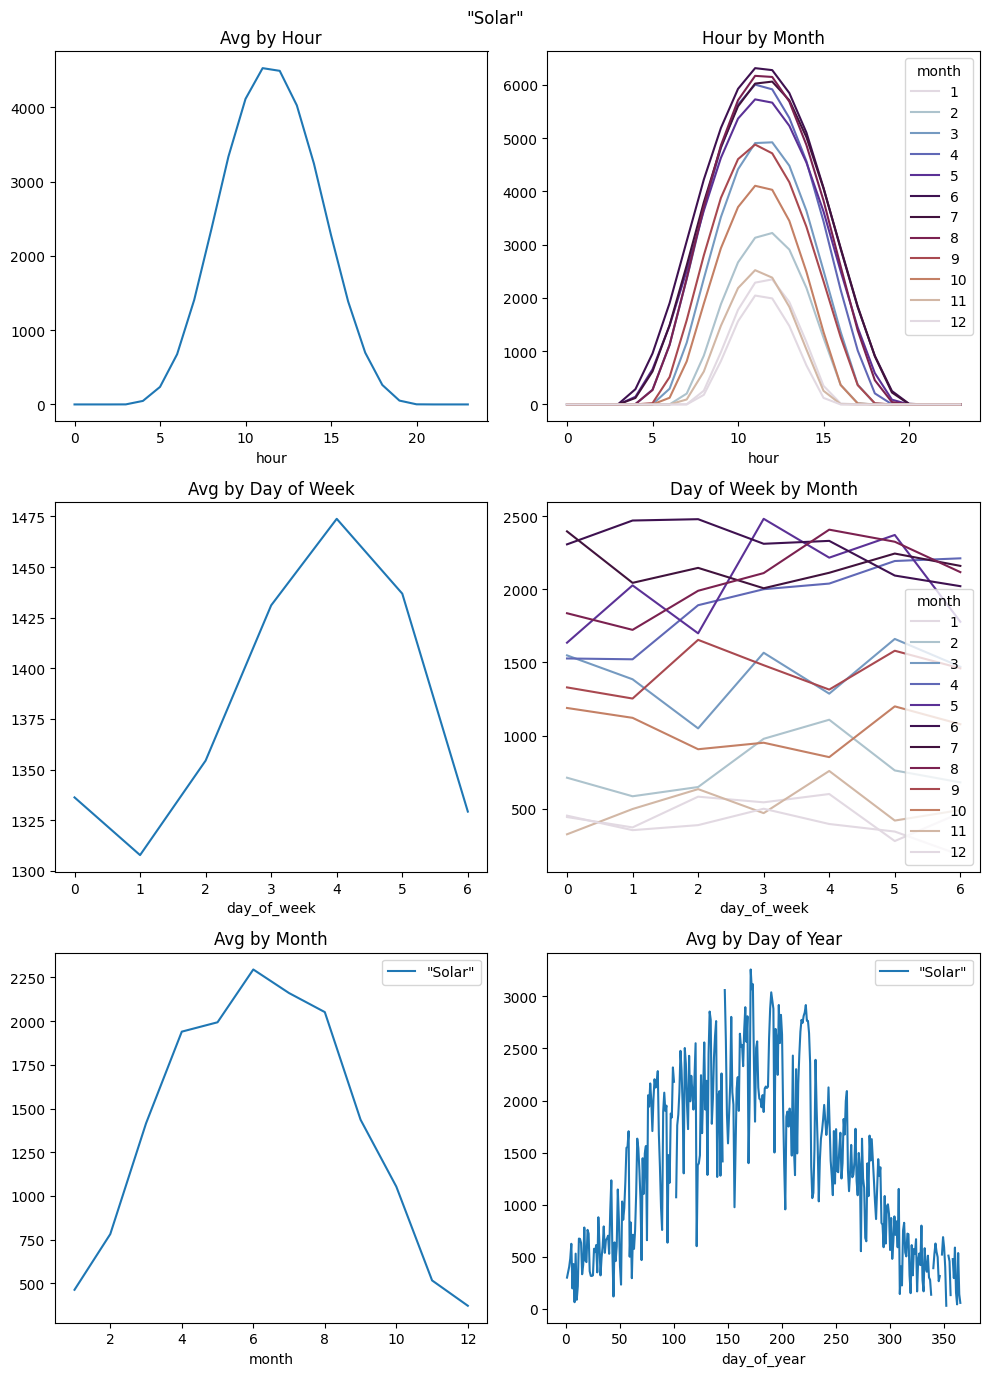

In [94]:
plot_column('"Solar"')

# Offshore Wind Generation (forecast) vs Time Interval Averages

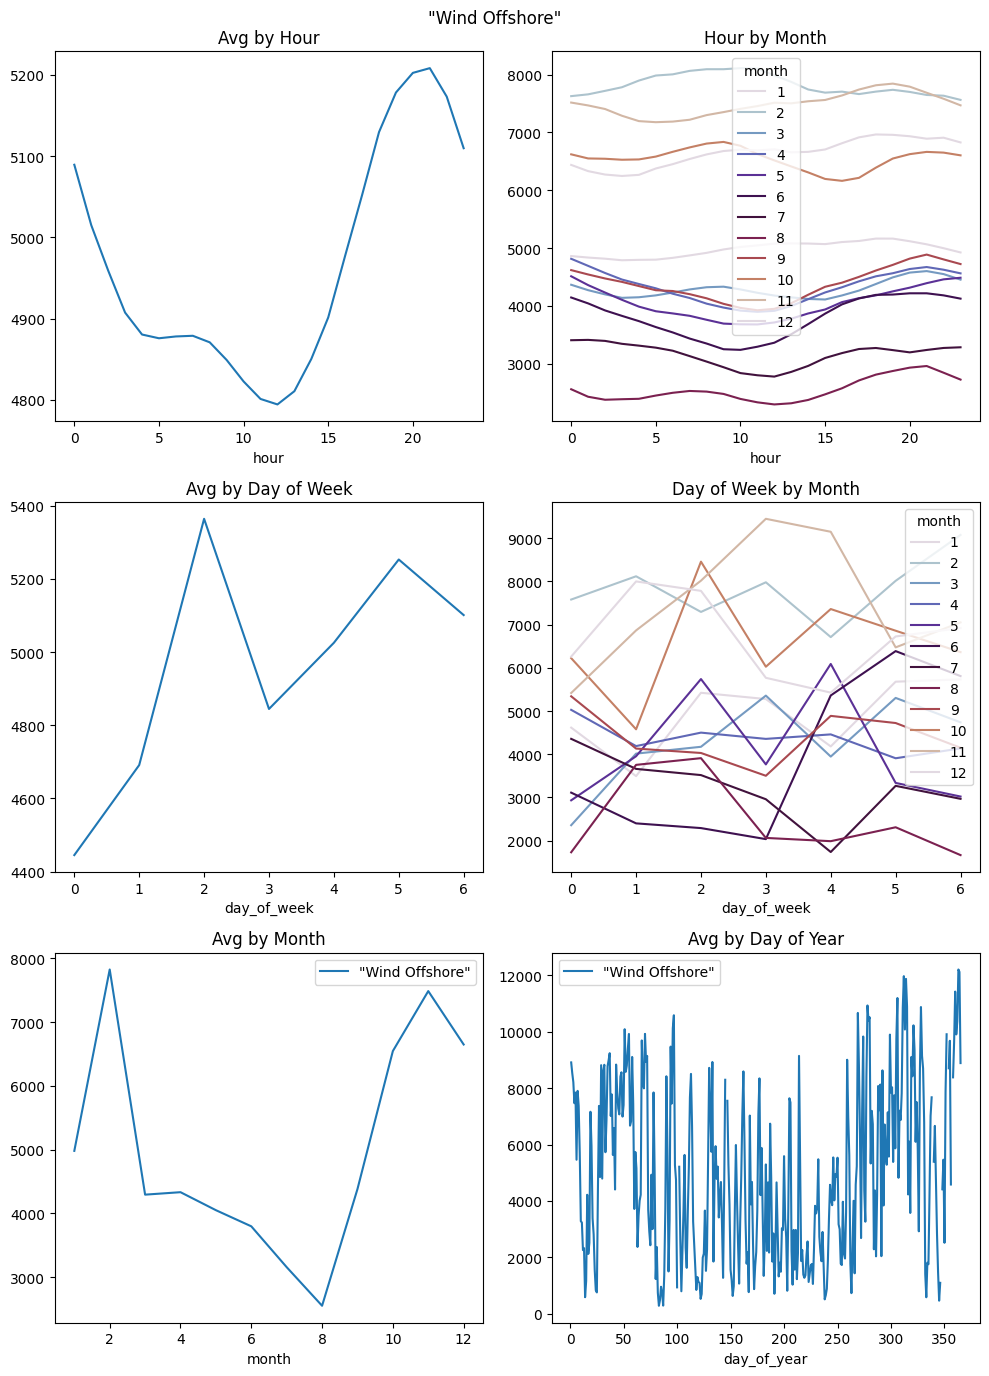

In [95]:
plot_column('"Wind Offshore"')

# Onshore Wind Generation (forecast) vs Time Interval Averages

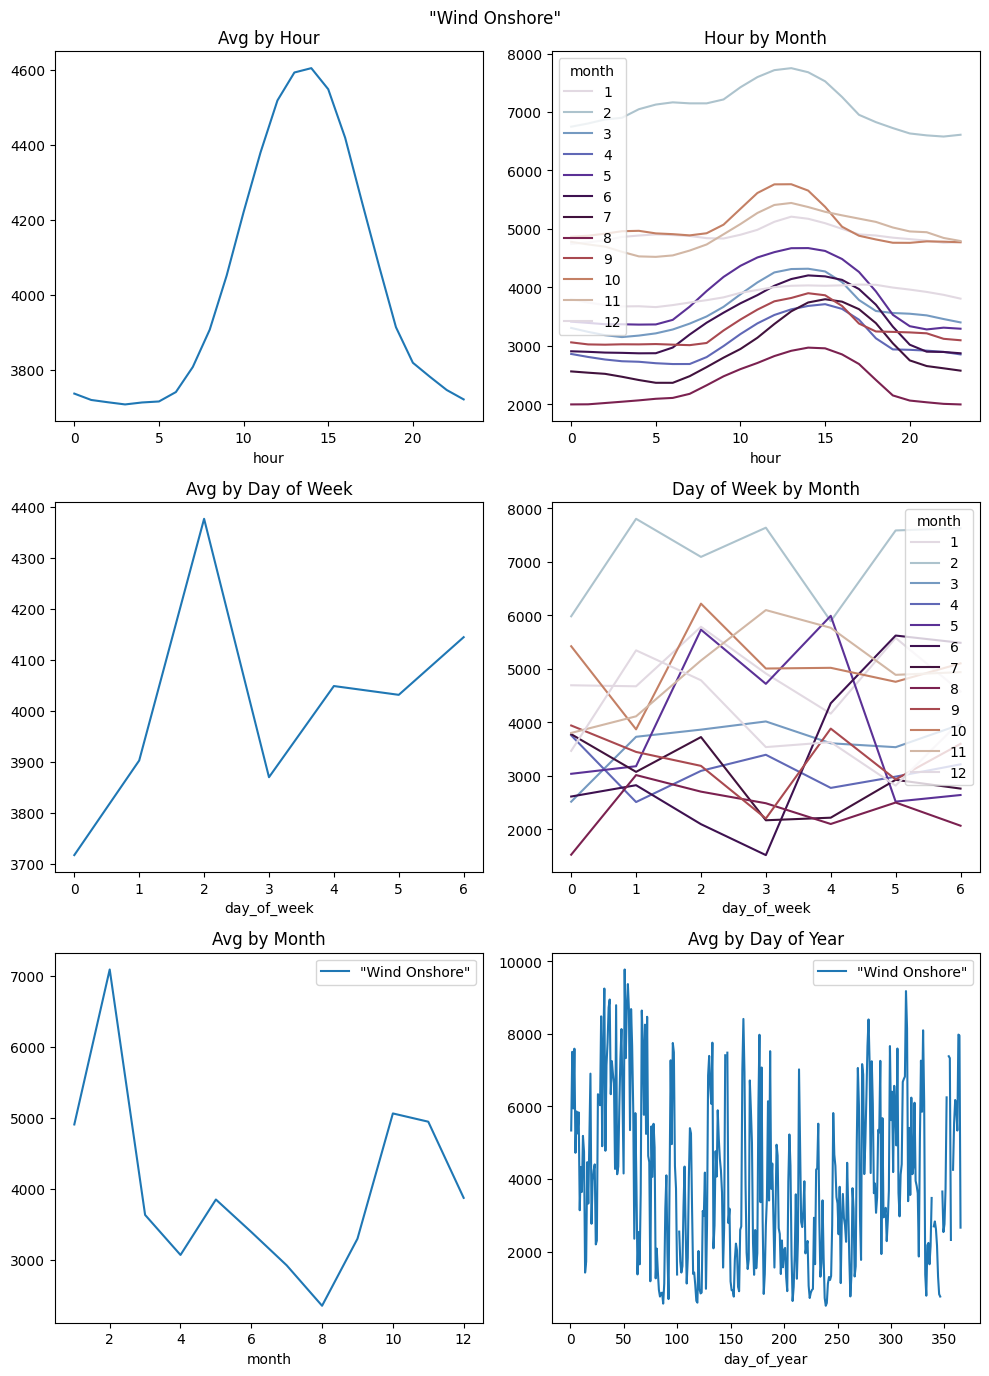

In [96]:
plot_column('"Wind Onshore"')

# Demand (forecast) vs Time Interval Averages

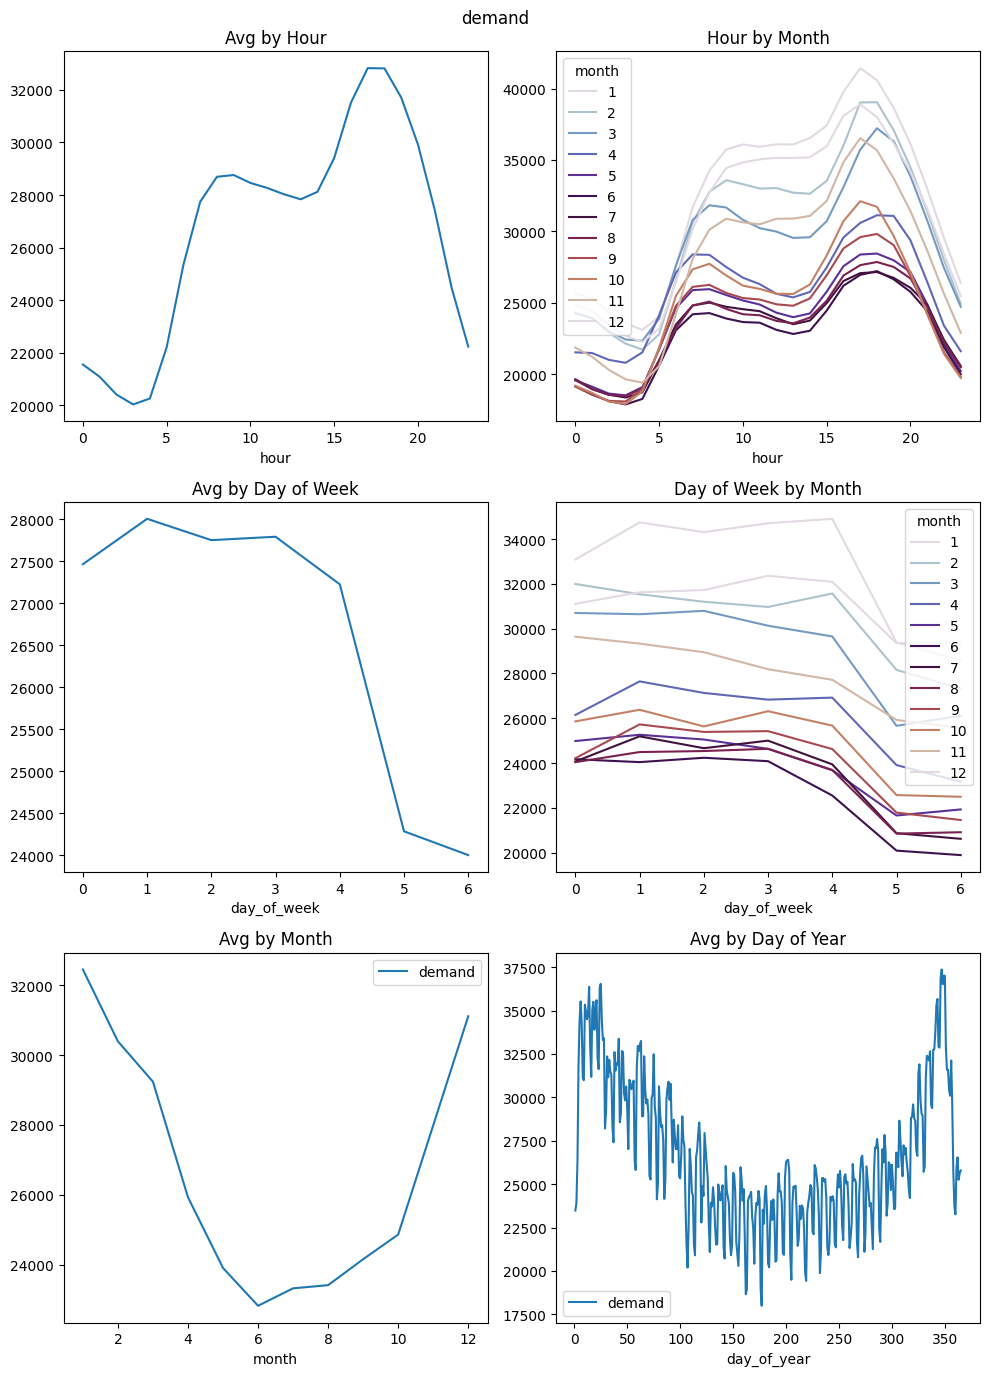

In [97]:
plot_column("demand")